# Credit Card Default Prediction - Comprehensive Systematic Analysis

## Project Overview
**Objective:** Build a robust machine learning classification model to predict credit card default risk

**Dataset:** Taiwan Credit Card Client Default Data (30,000 records)

**Key Challenge:** Severe class imbalance (78% non-default vs 22% default)

---

## Table of Contents
1. **Data Understanding & Preparation**
2. **Exploratory Data Analysis**
3. **Feature Engineering & Preprocessing**
4. **Class Imbalance Handling**
5. **Baseline Model Evaluation**
6. **Automatic Model Selection & Hyperparameter Tuning**
7. **Comprehensive Model Comparison**
9. **Threshold Optimization**


---
# SECTION 1: LIBRARIES & INITIAL SETUP
---

In [20]:
# Core Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import joblib

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

# Metrics & Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, precision_recall_curve, roc_curve,
    auc
)

# Imbalanced Learning
from imblearn.over_sampling import SMOTE

# Statistics
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

print("✅ All libraries imported successfully!")
print(f"\n📊 Analysis Started: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}")



✅ All libraries imported successfully!

📊 Analysis Started: 2026-05-09 07:36:16


---
# SECTION 2: DATA LOADING & UNDERSTANDING
---

In [4]:
# Load Dataset
df = pd.read_csv('Credit_Card_Default.csv')

print("\n" + "="*80)
print("DATASET OVERVIEW")
print("="*80)

print(f"\n📋 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

print(f"\n🔍 Data Types:\n{df.dtypes}")

print(f"\n📊 Statistical Summary:")
display(df.describe().T)

print(f"\n🎯 Target Variable Distribution:")
target_dist = df['default.payment.next.month'].value_counts()
print(f"Non-Default (0): {target_dist[0]:,} ({target_dist[0]/len(df)*100:.1f}%)")
print(f"Default (1): {target_dist[1]:,} ({target_dist[1]/len(df)*100:.1f}%)")
print(f"Class Imbalance Ratio: {target_dist[0]/target_dist[1]:.2f}:1")

print(f"\n🔎 First Few Rows:")
display(df.head())


DATASET OVERVIEW

📋 Shape: 30,000 rows × 25 columns

🔍 Data Types:
ID                              int64
LIMIT_BAL                     float64
SEX                             int64
EDUCATION                       int64
MARRIAGE                        int64
AGE                             int64
PAY_0                           int64
PAY_2                           int64
PAY_3                           int64
PAY_4                           int64
PAY_5                           int64
PAY_6                           int64
BILL_AMT1                     float64
BILL_AMT2                     float64
BILL_AMT3                     float64
BILL_AMT4                     float64
BILL_AMT5                     float64
BILL_AMT6                     float64
PAY_AMT1                      float64
PAY_AMT2                      float64
PAY_AMT3                      float64
PAY_AMT4                      float64
PAY_AMT5                      float64
PAY_AMT6                      float64
default.payment.next

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0



🎯 Target Variable Distribution:
Non-Default (0): 23,364 (77.9%)
Default (1): 6,636 (22.1%)
Class Imbalance Ratio: 3.52:1

🔎 First Few Rows:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


---
## 2.1 Data Quality Assessment

In [5]:
print("\n" + "="*80)
print("DATA QUALITY ASSESSMENT")
print("="*80)

# Missing Values
missing = df.isnull().sum().sum()
print(f"\n🔴 Missing Values: {missing}")

# Duplicates
duplicates = df.duplicated().sum()
print(f"🔴 Duplicate Rows: {duplicates}")

# Data Cleaning
if 'ID' in df.columns:
    df = df.drop(columns=['ID'])
    print(f"✅ Removed 'ID' column (non-predictive)")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"✅ Removed {duplicates} duplicate rows")

print(f"\n✅ Cleaned Dataset Shape: {df.shape}")


DATA QUALITY ASSESSMENT

🔴 Missing Values: 0
🔴 Duplicate Rows: 0
✅ Removed 'ID' column (non-predictive)

✅ Cleaned Dataset Shape: (30000, 24)


---
# SECTION 3: EXPLORATORY DATA ANALYSIS (EDA)
---

## 3.1 Univariate Analysis


UNIVARIATE ANALYSIS - DISTRIBUTION OF KEY FEATURES


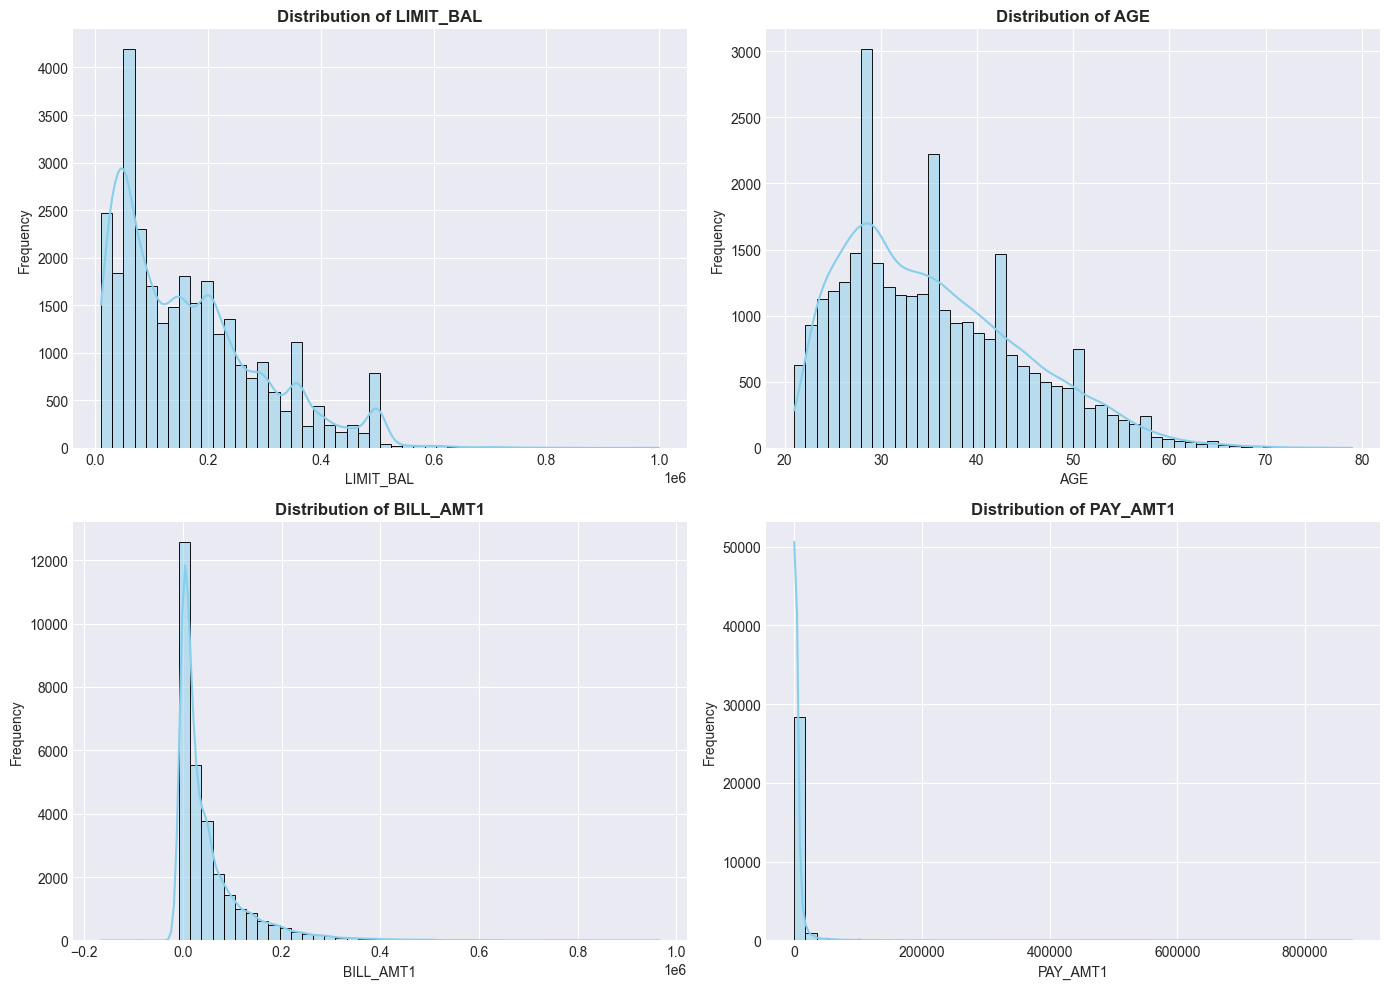


📈 Skewness Analysis:


,Feature,Skewness,Kurtosis
3,PAY_AMT1,14.668364,415.254743
2,BILL_AMT1,2.663861,9.806289
0,LIMIT_BAL,0.992867,0.536263
1,AGE,0.732246,0.044303


In [6]:
# Numerical Features for EDA
num_cols = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1']

print("\n" + "="*80)
print("UNIVARIATE ANALYSIS - DISTRIBUTION OF KEY FEATURES")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for idx, col in enumerate(num_cols):
    ax = axes[idx//2, idx%2]
    sns.histplot(df[col], bins=50, kde=True, color='skyblue', ax=ax)
    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Skewness Analysis
print("\n📈 Skewness Analysis:")
skewness_df = pd.DataFrame({
    'Feature': num_cols,
    'Skewness': [df[col].skew() for col in num_cols],
    'Kurtosis': [df[col].kurtosis() for col in num_cols]
}).sort_values('Skewness', ascending=False)
display(skewness_df)

## 3.2 Bivariate Analysis


CORRELATION & RELATIONSHIP ANALYSIS


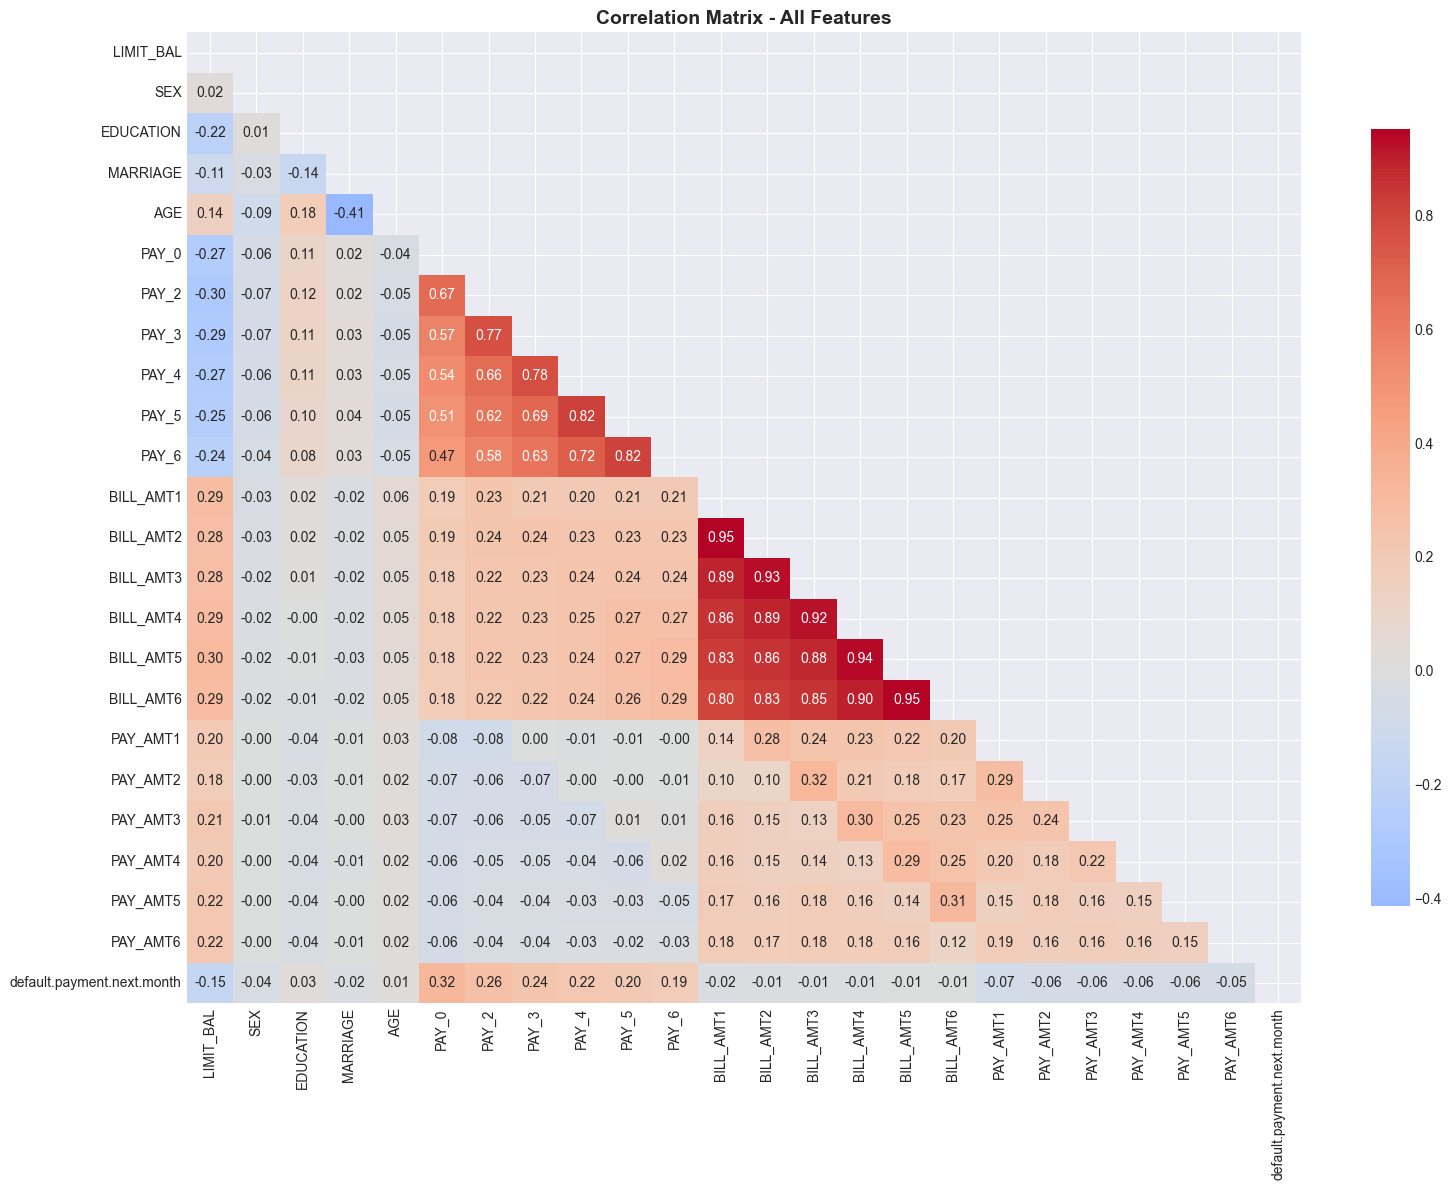

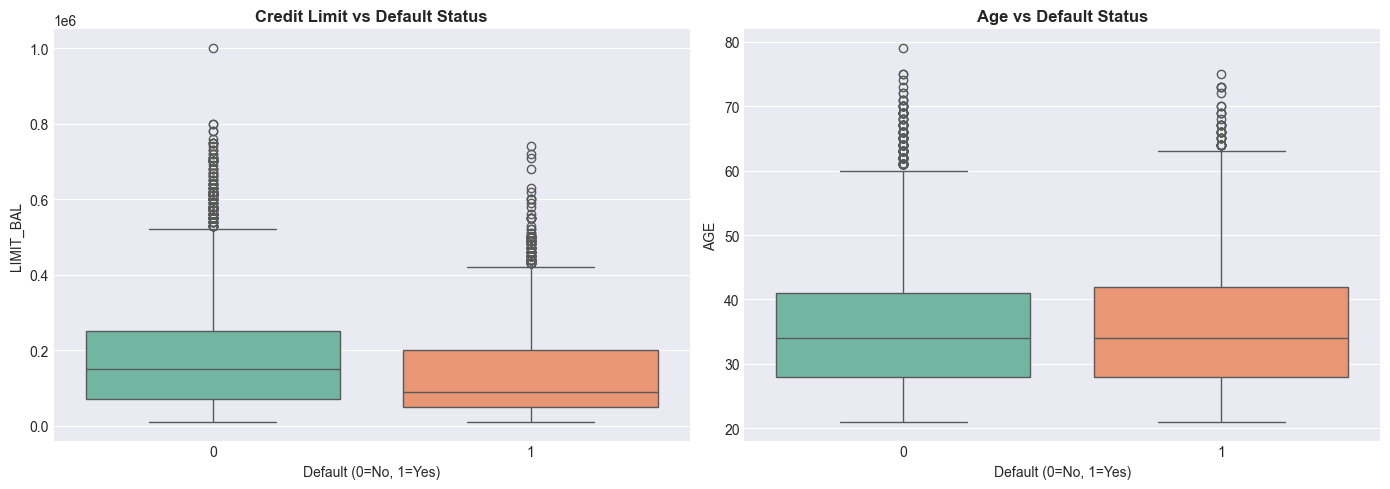

In [7]:
print("\n" + "="*80)
print("CORRELATION & RELATIONSHIP ANALYSIS")
print("="*80)

# Correlation Heatmap
fig, ax = plt.subplots(figsize=(16, 12))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix - All Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Features vs Target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x='default.payment.next.month', y='LIMIT_BAL', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Credit Limit vs Default Status', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Default (0=No, 1=Yes)')

sns.boxplot(x='default.payment.next.month', y='AGE', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Age vs Default Status', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Default (0=No, 1=Yes)')

plt.tight_layout()
plt.show()

## 3.3 Target Class Distribution

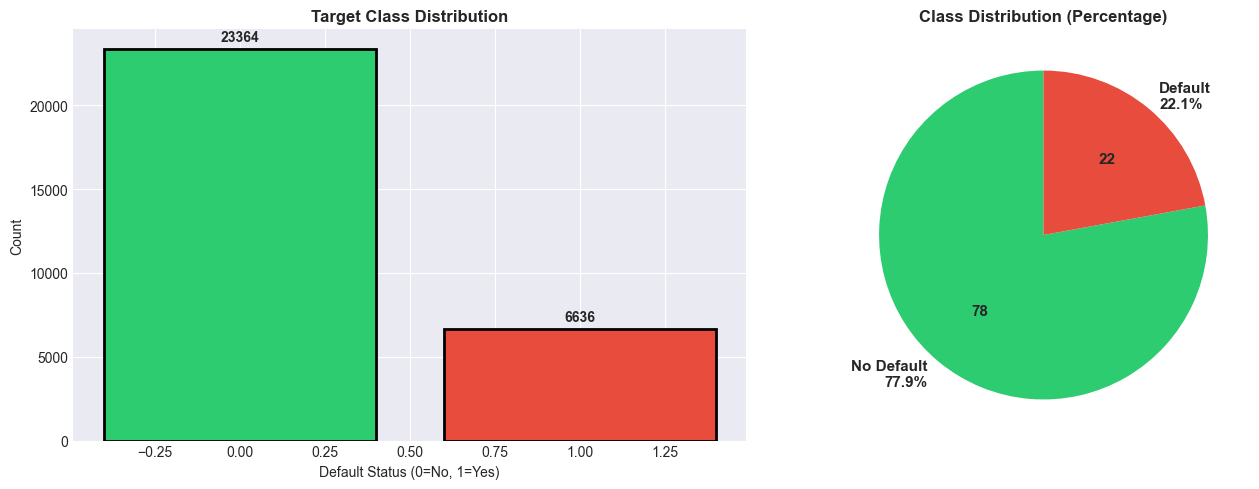


⚠️  CLASS IMBALANCE DETECTED:
   - Class Imbalance Ratio: 3.52:1
   - Minority Class (Default): 6636 samples (22.1%)
   - This will require resampling techniques like SMOTE!


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
ax1 = axes[0]
counts = df['default.payment.next.month'].value_counts()
colors = ['#2ecc71', '#e74c3c']
ax1.bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=2)
ax1.set_title('Target Class Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('Default Status (0=No, 1=Yes)')
ax1.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax1.text(i, v + 500, str(v), ha='center', fontweight='bold')

# Pie chart
ax2 = axes[1]
percentages = (counts.values / len(df) * 100)
ax2.pie(counts.values, labels=[f'No Default\n{percentages[0]:.1f}%', f'Default\n{percentages[1]:.1f}%'],
        autopct='%1.0f', colors=colors, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax2.set_title('Class Distribution (Percentage)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n⚠️  CLASS IMBALANCE DETECTED:")
print(f"   - Class Imbalance Ratio: {counts[0]/counts[1]:.2f}:1")
print(f"   - Minority Class (Default): {counts[1]} samples ({percentages[1]:.1f}%)")
print(f"   - This will require resampling techniques like SMOTE!")

---
# SECTION 4: PREPROCESSING
---

## 4.1 Outlier Detection & Treatment


OUTLIER DETECTION & TREATMENT (IQR METHOD)


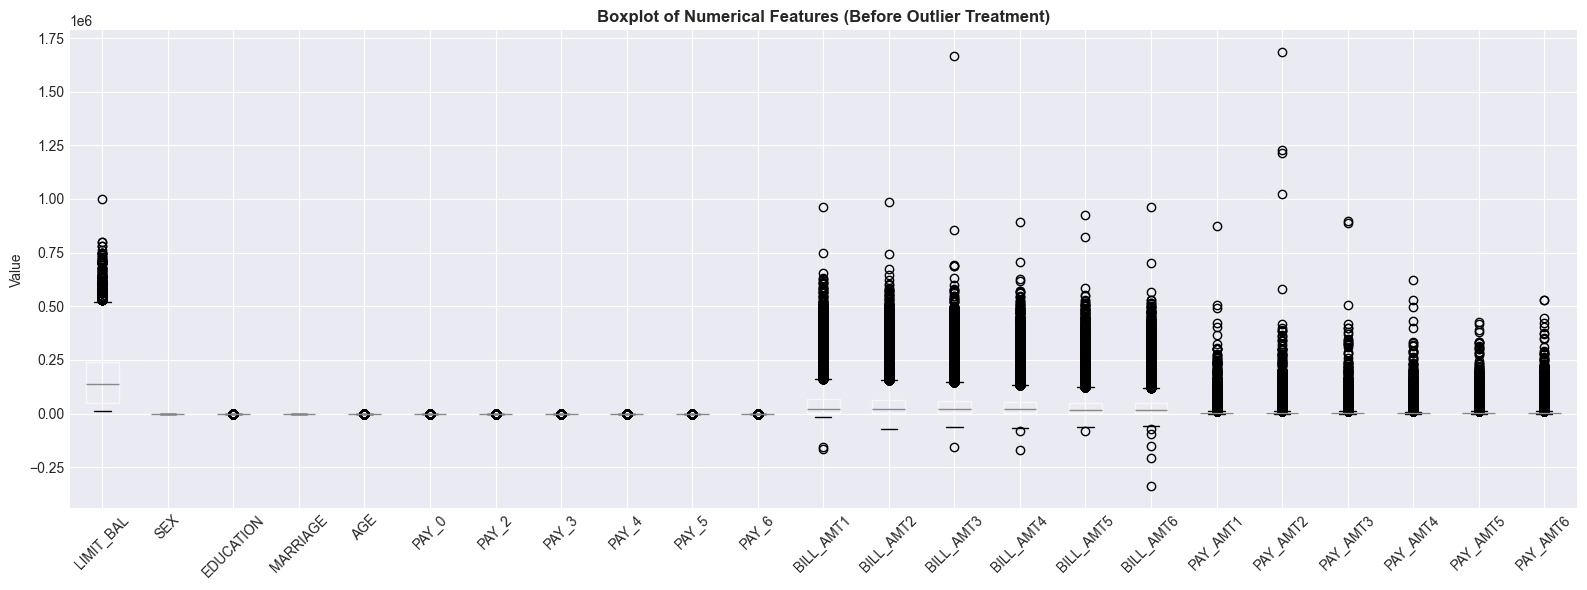


✅ Outliers Detected & Capped:


,Feature,Outliers
6,PAY_2,4410
7,PAY_3,4209
8,PAY_4,3508
5,PAY_0,3130
10,PAY_6,3079
20,PAY_AMT4,2994
9,PAY_5,2968
22,PAY_AMT6,2958
21,PAY_AMT5,2945
17,PAY_AMT1,2745



📊 Total outliers capped: 54455


In [9]:
print("\n" + "="*80)
print("OUTLIER DETECTION & TREATMENT (IQR METHOD)")
print("="*80)

num_cols_full = df.select_dtypes(include=[np.number]).columns.tolist()
if 'default.payment.next.month' in num_cols_full:
    num_cols_full.remove('default.payment.next.month')

# Boxplot Before Treatment
fig, ax = plt.subplots(figsize=(16, 6))
df[num_cols_full].boxplot(ax=ax)
ax.set_title('Boxplot of Numerical Features (Before Outlier Treatment)', fontsize=12, fontweight='bold')
ax.set_ylabel('Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# IQR Capping
outlier_counts = {}
for col in num_cols_full:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_before = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_counts[col] = outliers_before

    df[col] = np.where(df[col] < lower_bound, lower_bound,
                       np.where(df[col] > upper_bound, upper_bound, df[col]))

print(f"\n✅ Outliers Detected & Capped:")
outlier_summary = pd.DataFrame(list(outlier_counts.items()), columns=['Feature', 'Outliers'])
outlier_summary = outlier_summary[outlier_summary['Outliers'] > 0].sort_values('Outliers', ascending=False)
display(outlier_summary)

print(f"\n📊 Total outliers capped: {sum(outlier_counts.values())}")

## 4.2 Multicollinearity Analysis (VIF)

In [10]:
print("\n" + "="*80)
print("MULTICOLLINEARITY ANALYSIS (VARIANCE INFLATION FACTOR)")
print("="*80)

# Calculate VIF
vif_data = pd.DataFrame()
features = df.drop(columns=['default.payment.next.month'])
vif_data['Feature'] = features.columns
vif_data['VIF'] = [variance_inflation_factor(features.values, i) for i in range(len(features.columns))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print(f"\n📊 Variance Inflation Factor (VIF) Results:")
print(f"\n⚠️  Features with HIGH multicollinearity (VIF > 10):")
high_vif = vif_data[vif_data['VIF'] > 10]
if len(high_vif) > 0:
    display(high_vif)
else:
    print("None found - Good!")

display(vif_data.head(15))

# Feature Selection
cols_to_drop = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
print(f"\n🔴 Dropping highly correlated columns: {cols_to_drop}")
print(f"   (Keeping BILL_AMT1 as representative)")
df = df.drop(columns=cols_to_drop)

print(f"✅ Features reduced from {len(features.columns)} to {len(df.columns)-1}")


MULTICOLLINEARITY ANALYSIS (VARIANCE INFLATION FACTOR)

📊 Variance Inflation Factor (VIF) Results:

⚠️  Features with HIGH multicollinearity (VIF > 10):


,Feature,VIF
12,BILL_AMT2,32.391447
15,BILL_AMT5,29.508133
13,BILL_AMT3,28.641089
14,BILL_AMT4,27.358108
16,BILL_AMT6,18.811059
11,BILL_AMT1,18.135634
4,AGE,11.585742


,Feature,VIF
12,BILL_AMT2,32.391447
15,BILL_AMT5,29.508133
13,BILL_AMT3,28.641089
14,BILL_AMT4,27.358108
16,BILL_AMT6,18.811059
11,BILL_AMT1,18.135634
4,AGE,11.585742
1,SEX,9.231238
2,EDUCATION,7.729498
3,MARRIAGE,6.360383



🔴 Dropping highly correlated columns: ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
   (Keeping BILL_AMT1 as representative)
✅ Features reduced from 23 to 18


---
# SECTION 5: TRAIN-TEST SPLIT , SCALING & DATA PREPARATION
---

In [11]:
print("\n" + "="*80)
print("TRAIN-TEST SPLIT WITH STRATIFICATION")
print("="*80)

# Separate Features and Target
X = df.drop(columns=['default.payment.next.month'])
y = df['default.payment.next.month']

# Stratified Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n📊 Data Split Summary:")
print(f"   Training Set: {X_train.shape[0]:,} samples")
print(f"   Testing Set: {X_test.shape[0]:,} samples")
print(f"   Features: {X_train.shape[1]}")

print(f"\n📈 Class Distribution - Training Set:")
train_dist = y_train.value_counts()
print(f"   Non-Default: {train_dist[0]:,} ({train_dist[0]/len(y_train)*100:.1f}%)")
print(f"   Default: {train_dist[1]:,} ({train_dist[1]/len(y_train)*100:.1f}%)")

print(f"\n📈 Class Distribution - Testing Set:")
test_dist = y_test.value_counts()
print(f"   Non-Default: {test_dist[0]:,} ({test_dist[0]/len(y_test)*100:.1f}%)")
print(f"   Default: {test_dist[1]:,} ({test_dist[1]/len(y_test)*100:.1f}%)")

print(f"\n✅ Stratification preserved class ratios in both sets!")


TRAIN-TEST SPLIT WITH STRATIFICATION

📊 Data Split Summary:
   Training Set: 24,000 samples
   Testing Set: 6,000 samples
   Features: 18

📈 Class Distribution - Training Set:
   Non-Default: 18,691 (77.9%)
   Default: 5,309 (22.1%)

📈 Class Distribution - Testing Set:
   Non-Default: 4,673 (77.9%)
   Default: 1,327 (22.1%)

✅ Stratification preserved class ratios in both sets!


## 5.1 Feature Scaling & Normalization

In [12]:
print("\n" + "="*80)
print("FEATURE SCALING & NORMALIZATION")
print("="*80)

# Identify numerical features after dropping high VIF columns
num_cols_for_scaling = df.select_dtypes(include=[np.number]).columns.tolist()
if 'default.payment.next.month' in num_cols_for_scaling:
    num_cols_for_scaling.remove('default.payment.next.month')

scaler = StandardScaler()
df[num_cols_for_scaling] = scaler.fit_transform(df[num_cols_for_scaling])
# x_train_scaled = scaler.fit_transform(X_train)
# x_test_scaled = scaler.fit_transform(X_test)

# X_train = pd.DataFrame(x_train_scaled, columns=X_train.columns)
# X_test = pd.DataFrame(x_test_scaled, columns=X_test.columns)

# print(f"\n📊 Data Scaling Summary:")
# print(f"   Training Set: {X_train.shape[0]:,} samples")
# print(f"   Testing Set: {X_test.shape[0]:,} samples")
# print(f"   Features: {X_train.shape[1]}")


print(f"\n✅ Applied StandardScaler to {len(num_cols_for_scaling)} numerical features")
print(f"\n📊 Sample of scaled data:")
display(df[num_cols_for_scaling].head())

print(f"\n📈 Scaled Feature Statistics:")
display(df[num_cols_for_scaling].describe().T)


FEATURE SCALING & NORMALIZATION

✅ Applied StandardScaler to 18 numerical features

📊 Sample of scaled data:


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,-1.148083,0.810161,0.230777,-1.057295,-1.257372,1.674463,1.746729,-0.743681,-0.717876,-1.752244,-1.685337,-0.787236,-1.001158,-0.773703,-0.904708,-0.884502,-0.882842,-0.866920
1,-0.366901,0.810161,0.230777,0.858557,-1.037733,-0.951679,1.746729,0.260863,0.313506,0.358003,1.919588,-0.811235,-1.001158,-0.685670,-0.606697,-0.559114,-0.882842,-0.228173
2,-0.601256,0.810161,0.230777,0.858557,-0.159179,0.098778,0.234293,0.260863,0.313506,0.358003,0.374620,-0.293494,-0.566536,-0.544137,-0.606697,-0.559114,-0.559640,0.729948
3,-0.913728,0.810161,0.230777,-1.057295,0.170278,0.098778,0.234293,0.260863,0.313506,0.358003,0.374620,0.052570,-0.428533,-0.397227,-0.547095,-0.526575,-0.537339,-0.547546
4,-0.913728,-1.234323,0.230777,-1.057295,2.366663,-0.951679,0.234293,-0.743681,0.313506,0.358003,0.374620,-0.695529,-0.428533,2.215885,2.075405,2.043994,-0.660155,-0.650065



📈 Scaled Feature Statistics:


,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,1.515825e-17,1.000017,-1.226201,-0.913728,-0.210665,0.570516,2.796883
SEX,30000.0,2.197946e-16,1.000017,-1.234323,-1.234323,0.810161,0.810161,0.810161
EDUCATION,30000.0,7.200166e-17,1.000017,-2.530261,-1.149742,0.230777,0.230777,2.301555
MARRIAGE,30000.0,-1.894781e-18,1.000017,-2.973147,-1.057295,0.858557,0.858557,2.774410
AGE,30000.0,5.779081e-17,1.000017,-1.586829,-0.818095,-0.159179,0.609555,2.751031
PAY_0,30000.0,0.000000e+00,1.000017,-2.002135,-0.951679,0.098778,0.098778,1.674463
PAY_2,30000.0,-2.084259e-17,1.000017,-1.782288,-0.773998,0.234293,0.234293,1.746729
PAY_3,30000.0,-5.802766e-17,1.000017,-1.748225,-0.743681,0.260863,0.260863,1.767680
PAY_4,30000.0,5.021169e-17,1.000017,-1.749259,-0.717876,0.313506,0.313506,1.860579
PAY_5,30000.0,-7.579123e-17,1.000017,-1.752244,-0.697120,0.358003,0.358003,1.940689


## 5.2 Handling Class Imbalance with SMOTE

In [13]:
print("\n" + "="*80)
print("CLASS IMBALANCE HANDLING WITH SMOTE")
print("="*80)

print(f"\n📌 SMOTE: Synthetic Minority Over-sampling Technique")
print(f"   - Creates synthetic samples for minority class")
print(f"   - Applied ONLY to training data (prevents data leakage)")
print(f"   - Test set remains unchanged")

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"\n📊 Before SMOTE:")
print(f"   Non-Default: {(y_train == 0).sum():,}")
print(f"   Default: {(y_train == 1).sum():,}")
print(f"   Ratio: {(y_train == 0).sum() / (y_train == 1).sum():.2f}:1")

print(f"\n📊 After SMOTE:")
print(f"   Non-Default: {(y_train_res == 0).sum():,}")
print(f"   Default: {(y_train_res == 1).sum():,}")
print(f"   Ratio: {(y_train_res == 0).sum() / (y_train_res == 1).sum():.2f}:1 (BALANCED)")

print(f"\n✅ Training set rebalanced! New shape: {X_train_res.shape}")


CLASS IMBALANCE HANDLING WITH SMOTE

📌 SMOTE: Synthetic Minority Over-sampling Technique
   - Creates synthetic samples for minority class
   - Applied ONLY to training data (prevents data leakage)
   - Test set remains unchanged

📊 Before SMOTE:
   Non-Default: 18,691
   Default: 5,309
   Ratio: 3.52:1

📊 After SMOTE:
   Non-Default: 18,691
   Default: 18,691
   Ratio: 1.00:1 (BALANCED)

✅ Training set rebalanced! New shape: (37382, 18)


---
# SECTION 6: BASELINE MODEL EVALUATION
---

In [14]:
print("\n" + "="*80)
print("MODEL SETUP & EVALUATION FRAMEWORK")
print("="*80)

# Define Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42),
    "LightGBM": LGBMClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

print(f"\n📋 Models to Evaluate: {len(models)}")
for name in models.keys():
    print(f"   ✓ {name}")

def evaluate_models(X_train, X_test, y_train, y_test, models_dict, data_label):
    """Comprehensive model evaluation function"""
    results = []

    for name, model in models_dict.items():
        # Train
        model.fit(X_train, y_train)

        # Predict
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Evaluate
        results.append({
            'Model': name,
            'Data': data_label,
            'Train_Acc': round(accuracy_score(y_train, y_pred_train), 4),
            'Test_Acc': round(accuracy_score(y_test, y_pred_test), 4),
            'Recall': round(recall_score(y_test, y_pred_test), 4),
            'Precision': round(precision_score(y_test, y_pred_test), 4),
            'F1-Score': round(f1_score(y_test, y_pred_test), 4),
            'ROC-AUC': round(roc_auc_score(y_test, y_pred_proba), 4)
        })

    return pd.DataFrame(results)

print(f"\n✅ Evaluation framework ready!")


MODEL SETUP & EVALUATION FRAMEWORK

📋 Models to Evaluate: 9
   ✓ Logistic Regression
   ✓ Decision Tree
   ✓ Random Forest
   ✓ Gradient Boosting
   ✓ XGBoost
   ✓ CatBoost
   ✓ LightGBM
   ✓ SVM
   ✓ KNN

✅ Evaluation framework ready!


## 6.1 Experiment 1: Baseline Models (Imbalanced Data)

In [15]:
print("\n" + "="*80)
print("EXPERIMENT 1: BASELINE MODELS ON IMBALANCED DATA")
print("="*80)

results_imbalanced = evaluate_models(X_train, X_test, y_train, y_test, models, "Imbalanced")
results_imbalanced = results_imbalanced.sort_values('ROC-AUC', ascending=False)

print(f"\n📊 Results on Imbalanced Training Data:")
display(results_imbalanced)

print(f"\n🔍 Key Observations:")
print(f"   ⚠️  High accuracy but poor recall on minority class (default)")
print(f"   ⚠️  Model favors majority class (non-default)")
print(f"   ✓ {results_imbalanced.iloc[0]['Model']} performs best (ROC-AUC: {results_imbalanced.iloc[0]['ROC-AUC']})")


EXPERIMENT 1: BASELINE MODELS ON IMBALANCED DATA
[LightGBM] [Info] Number of positive: 5309, number of negative: 18691
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000873 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1920
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221208 -> initscore=-1.258639
[LightGBM] [Info] Start training from score -1.258639

📊 Results on Imbalanced Training Data:


,Model,Data,Train_Acc,Test_Acc,Recall,Precision,F1-Score,ROC-AUC
3,Gradient Boosting,Imbalanced,0.8259,0.8193,0.3625,0.6690,0.4702,0.7761
5,CatBoost,Imbalanced,0.8581,0.8175,0.3647,0.6576,0.4692,0.7750
6,LightGBM,Imbalanced,0.8423,0.8180,0.3670,0.6590,0.4714,0.7742
4,XGBoost,Imbalanced,0.8925,0.8105,0.3595,0.6243,0.4562,0.7569
2,Random Forest,Imbalanced,0.9994,0.8132,0.3662,0.6345,0.4644,0.7490
0,Logistic Regression,Imbalanced,0.8030,0.8002,0.2102,0.6488,0.3176,0.7090
1,Decision Tree,Imbalanced,0.9994,0.7168,0.3911,0.3681,0.3792,0.6001
8,KNN,Imbalanced,0.8145,0.7530,0.1447,0.3562,0.2058,0.5987
7,SVM,Imbalanced,0.7788,0.7788,0.0000,0.0000,0.0000,0.4217



🔍 Key Observations:
   ⚠️  High accuracy but poor recall on minority class (default)
   ⚠️  Model favors majority class (non-default)
   ✓ Gradient Boosting performs best (ROC-AUC: 0.7761)


## 6.2 Experiment 2: Baseline Models (Balanced Data via SMOTE)

In [16]:
print("\n" + "="*80)
print("EXPERIMENT 2: BASELINE MODELS ON BALANCED DATA (SMOTE)")
print("="*80)

# Fresh models for balanced data
models_balanced = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42),
    "LightGBM": LGBMClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

results_balanced = evaluate_models(X_train_res, X_test, y_train_res, y_test, models_balanced, "Balanced")
results_balanced = results_balanced.sort_values('ROC-AUC', ascending=False)

print(f"\n📊 Results on Balanced Training Data (SMOTE):")
display(results_balanced)

print(f"\n🔍 Key Improvements After SMOTE:")
print(f"   ✅ Significantly improved recall on minority class (default detection)")
print(f"   ✅ Better ROC-AUC scores overall")
print(f"   ✓ {results_balanced.iloc[0]['Model']} performs best (ROC-AUC: {results_balanced.iloc[0]['ROC-AUC']})")


EXPERIMENT 2: BASELINE MODELS ON BALANCED DATA (SMOTE)
[LightGBM] [Info] Number of positive: 18691, number of negative: 18691
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004734 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4526
[LightGBM] [Info] Number of data points in the train set: 37382, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

📊 Results on Balanced Training Data (SMOTE):


,Model,Data,Train_Acc,Test_Acc,Recall,Precision,F1-Score,ROC-AUC
3,Gradient Boosting,Balanced,0.8760,0.8183,0.3866,0.6502,0.4849,0.7730
5,CatBoost,Balanced,0.9071,0.8155,0.3791,0.6399,0.4761,0.7713
6,LightGBM,Balanced,0.8896,0.8180,0.3760,0.6540,0.4775,0.7708
4,XGBoost,Balanced,0.9196,0.8078,0.3768,0.6053,0.4645,0.7563
2,Random Forest,Balanced,0.9996,0.8118,0.3986,0.6151,0.4838,0.7495
0,Logistic Regression,Balanced,0.6687,0.6438,0.6451,0.3394,0.4448,0.7081
7,SVM,Balanced,0.6125,0.5578,0.6466,0.2821,0.3928,0.6281
1,Decision Tree,Balanced,0.9996,0.7212,0.4205,0.3817,0.4001,0.6138
8,KNN,Balanced,0.8441,0.6098,0.5207,0.2884,0.3712,0.6068



🔍 Key Improvements After SMOTE:
   ✅ Significantly improved recall on minority class (default detection)
   ✅ Better ROC-AUC scores overall
   ✓ Gradient Boosting performs best (ROC-AUC: 0.773)



IMBALANCED vs BALANCED COMPARISON


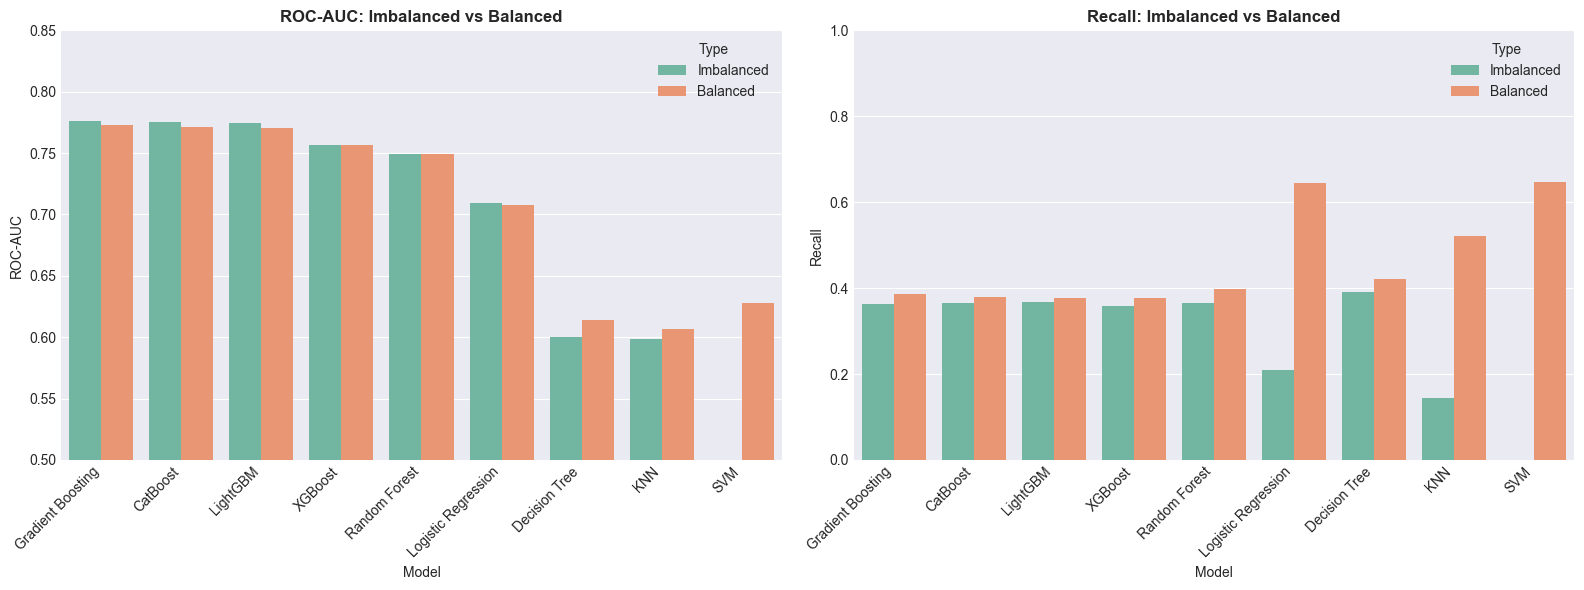


📊 Average Performance:
   Imbalanced - ROC-AUC: 0.6845, Recall: 0.2851
   Balanced   - ROC-AUC: 0.7086, Recall: 0.4611


In [17]:
print("\n" + "="*80)
print("IMBALANCED vs BALANCED COMPARISON")
print("="*80)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC-AUC Comparison
comparison_roc = pd.concat([
    results_imbalanced[['Model', 'ROC-AUC']].assign(Type='Imbalanced'),
    results_balanced[['Model', 'ROC-AUC']].assign(Type='Balanced')
])
sns.barplot(data=comparison_roc, x='Model', y='ROC-AUC', hue='Type', ax=axes[0], palette='Set2')
axes[0].set_title('ROC-AUC: Imbalanced vs Balanced', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_ylim(0.5, 0.85)

# Recall Comparison
comparison_recall = pd.concat([
    results_imbalanced[['Model', 'Recall']].assign(Type='Imbalanced'),
    results_balanced[['Model', 'Recall']].assign(Type='Balanced')
])
sns.barplot(data=comparison_recall, x='Model', y='Recall', hue='Type', ax=axes[1], palette='Set2')
axes[1].set_title('Recall: Imbalanced vs Balanced', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print(f"\n📊 Average Performance:")
print(f"   Imbalanced - ROC-AUC: {results_imbalanced['ROC-AUC'].mean():.4f}, Recall: {results_imbalanced['Recall'].mean():.4f}")
print(f"   Balanced   - ROC-AUC: {results_balanced['ROC-AUC'].mean():.4f}, Recall: {results_balanced['Recall'].mean():.4f}")

---
# SECTION 7: AUTOMATIC MODEL SELECTION & HYPERPARAMETER TUNING
---

In [18]:
# =============================================================================
# AUTOMATIC TOP MODEL SELECTION
# =============================================================================

def select_top_models_automatic(results_df, top_n=3, metric_weights=None):
    """Automatically select top models using composite weighted score"""

    if metric_weights is None:
        metric_weights = {
            'ROC-AUC': 0.35,
            'Recall': 0.30,
            'Precision': 0.15,
            'F1-Score': 0.20
        }

    df = results_df.copy()
    scaler = MinMaxScaler()
    metrics_to_normalize = list(metric_weights.keys())
    available_metrics = [m for m in metrics_to_normalize if m in df.columns]

    normalized_metrics = scaler.fit_transform(df[available_metrics])

    normalized_df = pd.DataFrame(
        normalized_metrics,
        columns=available_metrics,
        index=df.index
    )

    composite_scores = sum(
        normalized_df[metric] * weight
        for metric, weight in metric_weights.items()
        if metric in normalized_df.columns
    )

    df['Composite_Score'] = composite_scores

    df = df.sort_values(
        by='Composite_Score',
        ascending=False
    )

    top_models = df.head(top_n)['Model'].tolist()

    print(f"\n🏆 Top {top_n} Models (Composite Score)")
    print("=" * 80)

    for i, (idx, row) in enumerate(df.head(top_n).iterrows(), 1):

        print(f"\n{i}. {row['Model']}")
        print(f"   Composite Score: {row['Composite_Score']:.4f}")

        for metric in available_metrics:
            print(f"   • {metric}: {row[metric]:.4f}")

    return top_models, df


# =============================================================================
# SELECT TOP MODELS
# =============================================================================

print("\n" + "=" * 80)
print("AUTOMATIC TOP MODEL SELECTION")
print("=" * 80)

top_models_auto, top_models_scoring = select_top_models_automatic(
    results_balanced,
    top_n=3,
    metric_weights={
        'ROC-AUC': 0.35,
        'Recall': 0.30,
        'Precision': 0.15,
        'F1-Score': 0.20
    }
)

print(f"\n✅ Selected for Tuning: {top_models_auto}")

# =============================================================================
# GRID SEARCH PARAMETER GRIDS
# =============================================================================

print("\n" + "=" * 80)
print("GRID SEARCH HYPERPARAMETER TUNING")
print("=" * 80)

hyperparameter_grids = {

    "Logistic Regression": {
        'C': [0.001, 0.01, 0.1, 1, 10],
        'penalty': ['l2'],
        'solver': ['lbfgs']
    },

    "Decision Tree": {
        'max_depth': [3, 5, 7, 10, 15],
        'min_samples_split': [2, 5, 10]
    },

    "Random Forest": {
        'n_estimators': [100, 200],
        'max_depth': [5, 10, 15, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },

    "Gradient Boosting": {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 4, 5]
    },

    "XGBoost": {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 4, 5],
        'subsample': [0.8, 1.0]
    },

    "CatBoost": {
        'iterations': [100, 200],
        'learning_rate': [0.01, 0.05, 0.1],
        'depth': [3, 4, 5]
    },

    "LightGBM": {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 4, 5]
    }
}

print(f"\n📋 Grid Search Spaces:")

for model_name, grid in hyperparameter_grids.items():

    param_count = 1

    for param, values in grid.items():
        param_count *= len(values)

    print(f"   • {model_name}: {param_count} combinations")


# =============================================================================
# PERFORM GRID SEARCH CV
# =============================================================================

print("\n" + "=" * 80)
print("PERFORMING GRID SEARCH CV")
print("=" * 80)

best_tuned_models = {}

tuning_results_summary = []

start_time = time.time()

for model_name in top_models_auto:

    if model_name not in hyperparameter_grids:
        continue

    base_model = models_balanced[model_name]

    param_grid = hyperparameter_grids[model_name]

    print(f"\n🔍 Tuning Model: {model_name}")

    model_start = time.time()

    # -------------------------------------------------------------------------
    # GRID SEARCH CV
    # -------------------------------------------------------------------------

    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        scoring='roc_auc',
        cv=5,
        n_jobs=-1,
        verbose=1,
        return_train_score=True
    )

    # Fit model
    grid_search.fit(X_train_res, y_train_res)

    # Time taken
    model_time = time.time() - model_start

    # Store best model
    best_tuned_models[model_name] = grid_search.best_estimator_

    # -------------------------------------------------------------------------
    # EVALUATE BEST MODEL
    # -------------------------------------------------------------------------

    best_model = grid_search.best_estimator_

    y_pred = best_model.predict(X_test)

    y_pred_proba = best_model.predict_proba(X_test)[:, 1]

    roc_auc = roc_auc_score(y_test, y_pred_proba)

    recall = recall_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    # -------------------------------------------------------------------------
    # SAVE RESULTS
    # -------------------------------------------------------------------------

    tuning_results_summary.append({

        'Model': model_name,

        'Best_Params': str(grid_search.best_params_),

        'Best_CV_ROC_AUC': round(grid_search.best_score_, 4),

        'Test_ROC_AUC': round(roc_auc, 4),

        'Test_Recall': round(recall, 4),

        'Test_Precision': round(precision, 4),

        'Test_F1': round(f1, 4),

        'Time_Sec': round(model_time, 2)
    })

    # -------------------------------------------------------------------------
    # PRINT RESULTS
    # -------------------------------------------------------------------------

    print(f"\n✅ Best Parameters:")
    print(grid_search.best_params_)

    print(f"\n📊 Performance:")
    print(f"   • CV ROC-AUC     : {grid_search.best_score_:.4f}")
    print(f"   • Test ROC-AUC   : {roc_auc:.4f}")
    print(f"   • Recall         : {recall:.4f}")
    print(f"   • Precision      : {precision:.4f}")
    print(f"   • F1 Score       : {f1:.4f}")

    print(f"\n⏱️ Time Taken: {model_time:.2f} seconds")

# =============================================================================
# FINAL SUMMARY
# =============================================================================

total_time = time.time() - start_time

tuning_summary_df = pd.DataFrame(tuning_results_summary)

tuning_summary_df = tuning_summary_df.sort_values(
    by='Test_ROC_AUC',
    ascending=False
)

print("\n" + "=" * 80)
print("GRID SEARCH TUNING SUMMARY")
print("=" * 80)

print(f"\n⏱️ Total Tuning Time: {total_time/60:.2f} minutes")

display(tuning_summary_df)


AUTOMATIC TOP MODEL SELECTION

🏆 Top 3 Models (Composite Score)

1. Gradient Boosting
   Composite Score: 0.7102
   • ROC-AUC: 0.7730
   • Recall: 0.3866
   • Precision: 0.6502
   • F1-Score: 0.4849

2. LightGBM
   Composite Score: 0.6824
   • ROC-AUC: 0.7708
   • Recall: 0.3760
   • Precision: 0.6540
   • F1-Score: 0.4775

3. CatBoost
   Composite Score: 0.6787
   • ROC-AUC: 0.7713
   • Recall: 0.3791
   • Precision: 0.6399
   • F1-Score: 0.4761

✅ Selected for Tuning: ['Gradient Boosting', 'LightGBM', 'CatBoost']

GRID SEARCH HYPERPARAMETER TUNING

📋 Grid Search Spaces:
   • Logistic Regression: 5 combinations
   • Decision Tree: 15 combinations
   • Random Forest: 32 combinations
   • Gradient Boosting: 18 combinations
   • XGBoost: 36 combinations
   • CatBoost: 18 combinations
   • LightGBM: 18 combinations

PERFORMING GRID SEARCH CV

🔍 Tuning Model: Gradient Boosting
Fitting 5 folds for each of 18 candidates, totalling 90 fits

✅ Best Parameters:
{'learning_rate': 0.1, 'max_dept

,Model,Best_Params,Best_CV_ROC_AUC,Test_ROC_AUC,Test_Recall,Test_Precision,Test_F1,Time_Sec
2,CatBoost,"{'depth': 5, 'iterations': 200, 'learning_rate...",0.9331,0.7783,0.3768,0.6545,0.4782,722.51
1,LightGBM,"{'learning_rate': 0.1, 'max_depth': 4, 'n_esti...",0.9339,0.7716,0.3723,0.6509,0.4736,54.14
0,Gradient Boosting,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti...",0.9336,0.7681,0.3693,0.6422,0.4689,634.15


---
# SECTION 8: COMPREHENSIVE MODEL COMPARISON
---


COMPREHENSIVE MODEL COMPARISON

MODEL: Gradient Boosting

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.64      0.37      0.47      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.66      0.68      6000
weighted avg       0.80      0.81      0.80      6000



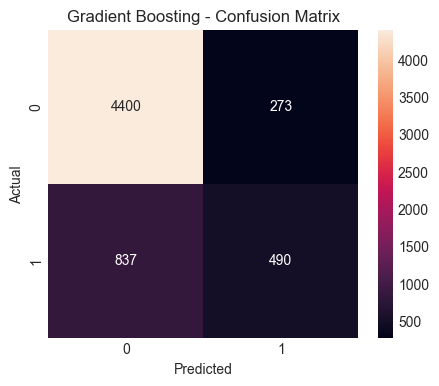

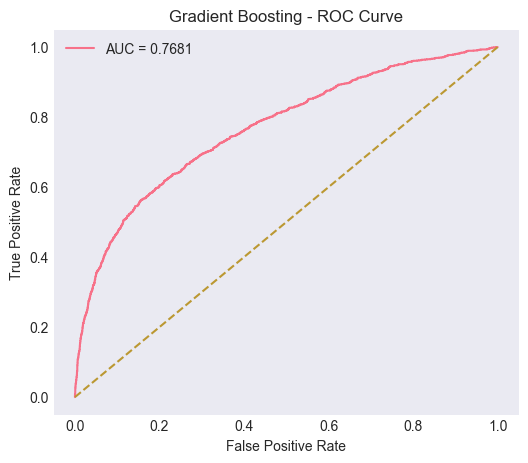

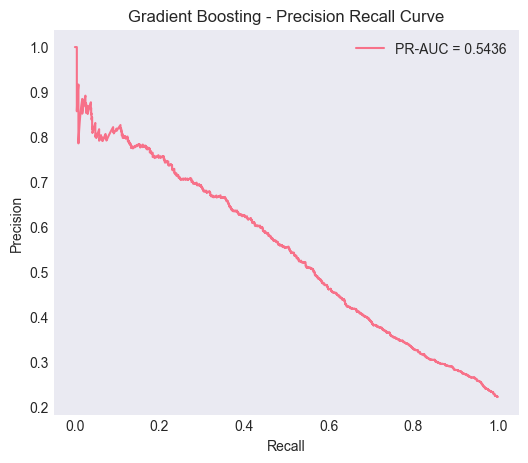


MODEL: LightGBM

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.65      0.37      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.66      0.68      6000
weighted avg       0.80      0.82      0.80      6000



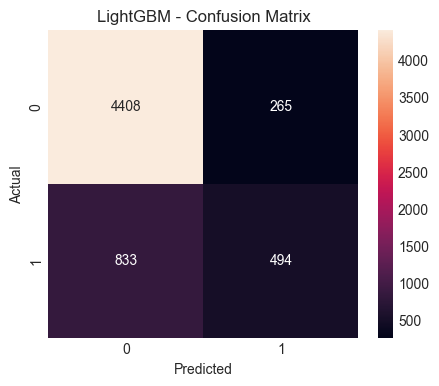

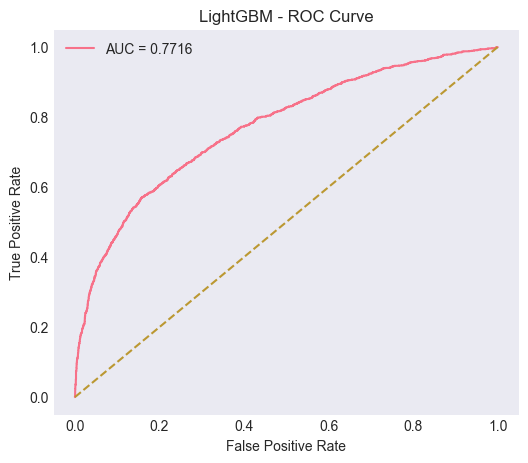

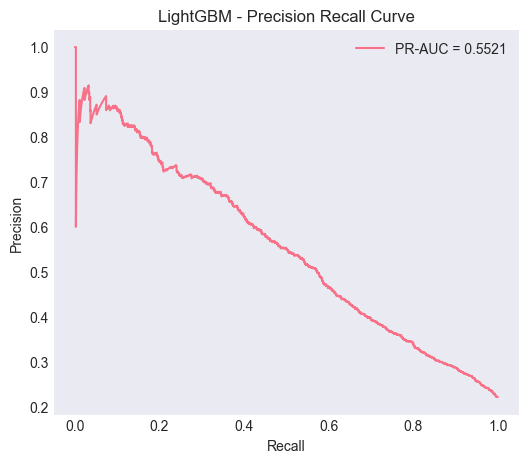


MODEL: CatBoost

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.65      0.38      0.48      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.66      0.68      6000
weighted avg       0.80      0.82      0.80      6000



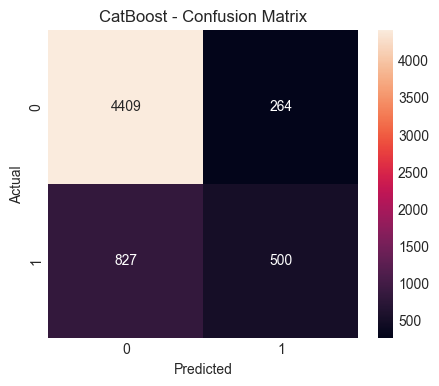

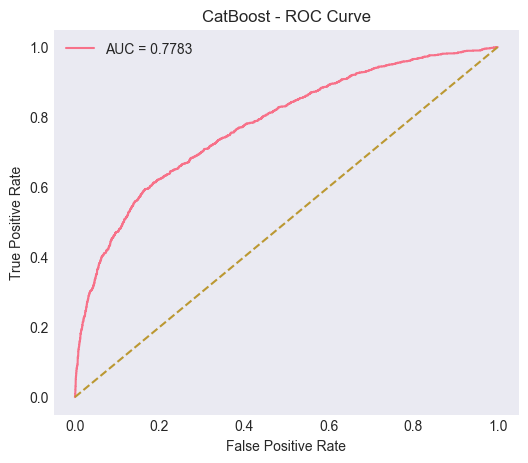

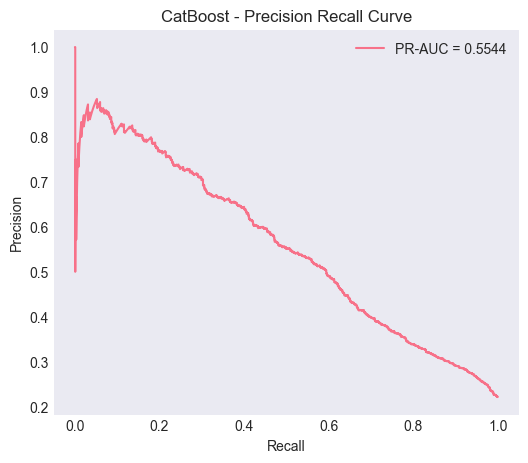


FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
2,CatBoost,0.8182,0.6545,0.3768,0.4782,0.7783,0.5544
1,LightGBM,0.8170,0.6509,0.3723,0.4736,0.7716,0.5521
0,Gradient Boosting,0.8150,0.6422,0.3693,0.4689,0.7681,0.5436


In [21]:
print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*80)

# =============================================================================
# EVALUATE TUNED MODELS
# =============================================================================

evaluation_results = []

for model_name, model in best_tuned_models.items():

    print("\n" + "="*80)
    print(f"MODEL: {model_name}")
    print("="*80)

    # Predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_precision, pr_recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(pr_recall, pr_precision)

    # Save results
    evaluation_results.append({
        'Model': model_name,
        'Accuracy': round(accuracy,4),
        'Precision': round(precision,4),
        'Recall': round(recall,4),
        'F1-Score': round(f1,4),
        'ROC-AUC': round(roc_auc,4),
        'PR-AUC': round(pr_auc,4)
    })

    # ---------------------------------------------------------
    # Classification Report
    # ---------------------------------------------------------

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # ---------------------------------------------------------
    # Confusion Matrix
    # ---------------------------------------------------------

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm,annot=True,fmt='d')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ---------------------------------------------------------
    # ROC CURVE
    # ---------------------------------------------------------

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
    plt.plot([0,1],[0,1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f'{model_name} - ROC Curve')
    plt.legend()
    plt.grid()
    plt.show()

    # ---------------------------------------------------------
    # PRECISION-RECALL CURVE
    # ---------------------------------------------------------

    plt.figure(figsize=(6,5))
    plt.plot(pr_recall, pr_precision,label=f'PR-AUC = {pr_auc:.4f}')
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f'{model_name} - Precision Recall Curve')
    plt.legend()
    plt.grid()
    plt.show()

# =============================================================================
# FINAL COMPARISON TABLE
# =============================================================================

results_df = pd.DataFrame(evaluation_results)
results_df = results_df.sort_values(by='ROC-AUC',ascending=False)
print("\n" + "="*80)
print("FINAL MODEL COMPARISON")
print("="*80)

display(results_df)

---
# SECTION 9: THRESHOLD OPTIMIZATION & COST ANALYSIS
---

In [22]:
# =============================================================================
# MODELS TO EVALUATE
# =============================================================================

models_for_threshold = {
    'CatBoost': best_tuned_models['CatBoost'],
    'LightGBM': best_tuned_models['LightGBM']
}

# =============================================================================
# BUSINESS COSTS
# =============================================================================

COST_FN = 10000   # Missed defaulter
COST_FP = 2000    # False alarm

# =============================================================================
# THRESHOLD SEARCH
# =============================================================================

thresholds = np.arange(0.10, 0.91, 0.05)

final_threshold_results = []

for model_name, model in models_for_threshold.items():

    print("\n" + "="*80)
    print(f"THRESHOLD OPTIMIZATION: {model_name}")
    print("="*80)

    # Probabilities
    y_probs = model.predict_proba(X_test)[:,1]

    model_results = []

    for threshold in thresholds:

        # Predictions
        y_pred = (y_probs >= threshold).astype(int)

        # Metrics
        accuracy = accuracy_score(y_test, y_pred)

        precision = precision_score(y_test, y_pred)

        recall = recall_score(y_test, y_pred)

        f1 = f1_score(y_test, y_pred)

        roc_auc = roc_auc_score(y_test, y_probs)

        # Confusion matrix
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

        # Business cost
        total_cost = (fn * COST_FN) + (fp * COST_FP)

        model_results.append({
            'Model': model_name,
            'Threshold': round(threshold, 2),
            'Accuracy': round(accuracy, 4),
            'Precision': round(precision, 4),
            'Recall': round(recall, 4),
            'F1-Score': round(f1, 4),
            'ROC-AUC': round(roc_auc, 4),
            'False Positives': fp,
            'False Negatives': fn,
            'Business Cost': total_cost
        })

    # Convert to DataFrame
    model_df = pd.DataFrame(model_results)

    # Best threshold = minimum cost
    best_row = model_df.sort_values(
        by='Business Cost'
    ).iloc[0]

    final_threshold_results.append(best_row)

    print(f"\n✅ BEST THRESHOLD FOR {model_name}")
    print("-"*50)

    print(f"Threshold        : {best_row['Threshold']}")
    print(f"Recall           : {best_row['Recall']}")
    print(f"Precision        : {best_row['Precision']}")
    print(f"F1-Score         : {best_row['F1-Score']}")
    print(f"ROC-AUC          : {best_row['ROC-AUC']}")
    print(f"Business Cost    : ₹{best_row['Business Cost']:,}")

# =============================================================================
# FINAL COMPARISON
# =============================================================================

final_threshold_df = pd.DataFrame(final_threshold_results)

final_threshold_df = final_threshold_df.sort_values(
    by='Business Cost'
)

print("\n" + "="*90)
print("FINAL THRESHOLD-OPTIMIZED MODEL COMPARISON")
print("="*90)

display(final_threshold_df)


THRESHOLD OPTIMIZATION: CatBoost

✅ BEST THRESHOLD FOR CatBoost
--------------------------------------------------
Threshold        : 0.2
Recall           : 0.7069
Precision        : 0.3963
F1-Score         : 0.5079
ROC-AUC          : 0.7783
Business Cost    : ₹6,748,000

THRESHOLD OPTIMIZATION: LightGBM

✅ BEST THRESHOLD FOR LightGBM
--------------------------------------------------
Threshold        : 0.2
Recall           : 0.7001
Precision        : 0.3948
F1-Score         : 0.5049
ROC-AUC          : 0.7716
Business Cost    : ₹6,828,000

FINAL THRESHOLD-OPTIMIZED MODEL COMPARISON


,Model,Threshold,Accuracy,Precision,Recall,F1-Score,ROC-AUC,False Positives,False Negatives,Business Cost
2,CatBoost,0.2,0.6970,0.3963,0.7069,0.5079,0.7783,1429,389,6748000
2,LightGBM,0.2,0.6963,0.3948,0.7001,0.5049,0.7716,1424,398,6828000
